Import all libraries

In [95]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

import pickle

Load Dataset

In [96]:
df = pd.read_csv("Country-data.csv")

print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


EDA

In [97]:
df = pd.read_csv("Country-data.csv")

print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


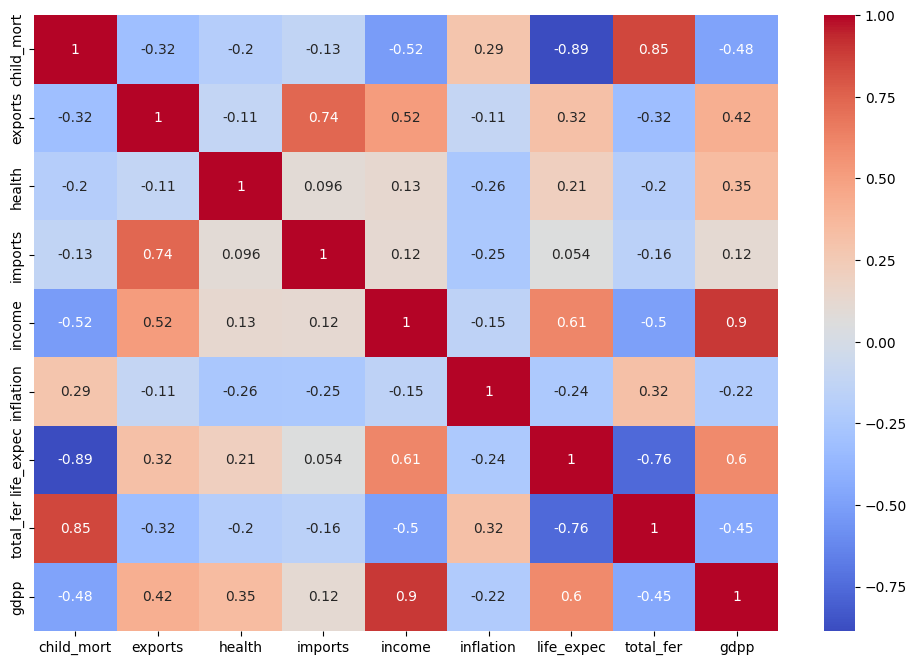

In [98]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Feature Scaling

In [99]:
X = df.drop("country",axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Find K - using Elbow Method

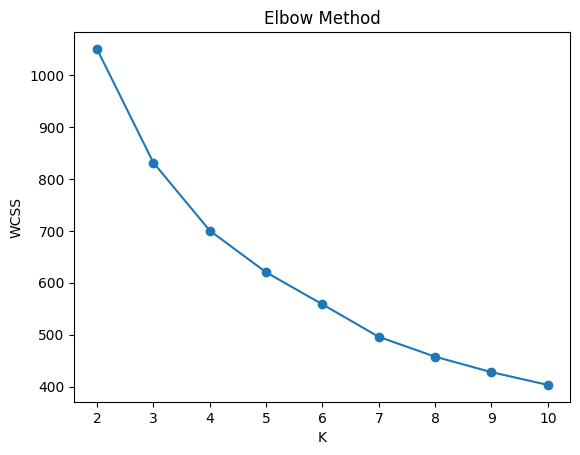

In [100]:
wcss = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(2,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Silhouette Score

In [101]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k} Score={score}")

K=2 Score=0.28735668921406704
K=3 Score=0.28329575683463126
K=4 Score=0.29595170577528157
K=5 Score=0.2992594995920442
K=6 Score=0.22869157246806018
K=7 Score=0.2476808104838398
K=8 Score=0.23881101831198853
K=9 Score=0.20731224410666968
K=10 Score=0.20223005028962746


In [102]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [103]:
#k = 3
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

wcss = []

K = range(1,11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

In [104]:
kn = KneeLocator(
    K,
    wcss,
    curve='convex',
    direction='decreasing'
)

print("Optimal K =", kn.knee)

Optimal K = 4


In [105]:
kmeans = KMeans(
    n_clusters=kn.knee,
    random_state=42,
    n_init=10
)

df["Segment"] = kmeans.fit_predict(X_scaled)

In [106]:
df["Segment"].value_counts()

Segment
2    85
1    47
0    32
3     3
Name: count, dtype: int64

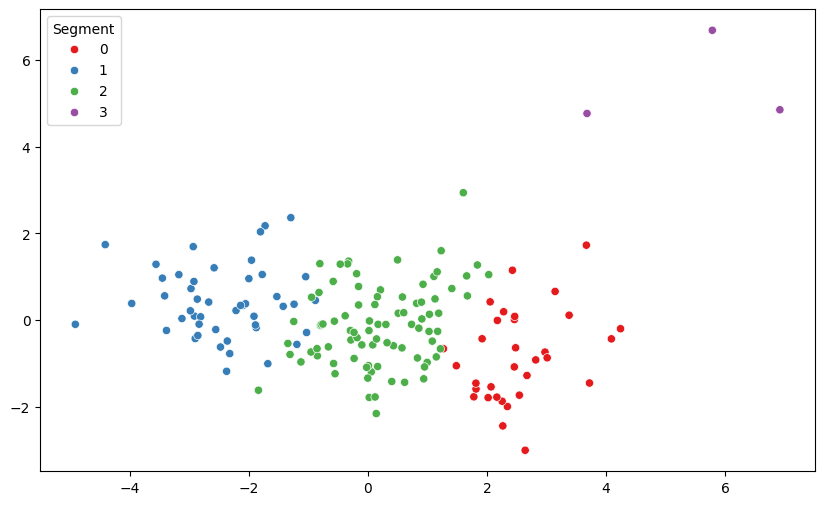

In [107]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Segment"],
    palette="Set1"
)

plt.show()

DBSCAN

In [108]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

print(np.unique(db_labels))

[-1  0]


In [109]:
X_cls = df.drop(
    ["country","Segment"],
    axis=1
)

y = df["Segment"]

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [111]:
scaler_cls = StandardScaler()

X_train = scaler_cls.fit_transform(X_train)

X_test = scaler_cls.transform(X_test)

In [112]:
models = {}

Logistic Regression

In [113]:
models["Logistic Regression"] = GridSearchCV(
    LogisticRegression(max_iter=5000),
    {"C":[0.01,0.1,1,10]},
    cv=5
)

Decision Tree

In [114]:
models["Decision Tree"] = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        "max_depth":[3,5,10,None],
        "min_samples_split":[2,5,10]
    },
    cv=5
)

Random Forest


In [115]:
models["Random Forest"] = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        "n_estimators":[100,200,300],
        "max_depth":[5,10,None]
    },
    cv=5
)

KNN

In [116]:
models["KNN"] = GridSearchCV(
    KNeighborsClassifier(),
    {
        "n_neighbors":[3,5,7,9]
    },
    cv=5
)

SVM

In [117]:
models["SVM"] = GridSearchCV(
    SVC(),
    {
        "C":[0.1,1,10],
        "kernel":["linear","rbf"]
    },
    cv=5
)

ADABOOST

In [118]:
models["AdaBoost"] = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    {
        "n_estimators":[50,100,200]
    },
    cv=5
)

GradientBoost

In [119]:
models["Gradient Boosting"] = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {
        "n_estimators":[100,200],
        "learning_rate":[0.01,0.1,0.2]
    },
    cv=5
)

XGBoost

In [120]:
models["XGBoost"] = GridSearchCV(
    XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    ),
    {
        "n_estimators":[100,200],
        "max_depth":[3,5],
        "learning_rate":[0.01,0.1]
    },
    cv=5
)

Naive Bayes

In [121]:
models["Naive Bayes"] = GaussianNB()

Train and Evaluation

In [122]:
results = []

best_model = None
best_score = 0
best_name = ""

In [123]:
for name, model in models.items():

    print("="*50)
    print(name)

    if name == "Naive Bayes":
        model.fit(X_train,y_train)
        pred = model.predict(X_test)

    else:
        model.fit(X_train,y_train)
        pred = model.best_estimator_.predict(X_test)

    acc = accuracy_score(y_test,pred)
    prec = precision_score(y_test,pred,average="weighted")
    rec = recall_score(y_test,pred,average="weighted")
    f1 = f1_score(y_test,pred,average="weighted")

    results.append(
        [name,acc,prec,rec,f1]
    )

    if acc > best_score:
        best_score = acc
        best_name = name

        if name == "Naive Bayes":
            best_model = model
        else:
            best_model = model.best_estimator_

    print(classification_report(y_test,pred))

Logistic Regression


c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00        10
           2       0.94      1.00      0.97        17
           3       1.00      1.00      1.00         1

    accuracy                           0.97        34
   macro avg       0.99      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34

Decision Tree


c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is i

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00        10
           2       0.89      1.00      0.94        17
           3       0.00      0.00      0.00         1

    accuracy                           0.94        34
   macro avg       0.72      0.71      0.71        34
weighted avg       0.92      0.94      0.93        34

Random Forest


...

c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is i

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.00      0.00      0.00        10
           2       0.59      1.00      0.74        17
           3       0.00      0.00      0.00         1

    accuracy                           0.65        34
   macro avg       0.40      0.46      0.41        34
weighted avg       0.47      0.65      0.53        34

Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00        10
           2       0.94      1.00      0.97        17
           3       1.00      1.00      1.00         1

    accuracy                           0.97        34
   macro avg       0.99      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34

XGBoost


c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00        10
           2       0.89      1.00      0.94        17
           3       0.00      0.00      0.00         1

    accuracy                           0.94        34
   macro avg       0.72      0.71      0.71        34
weighted avg       0.92      0.94      0.93        34

Naive Bayes
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        10
           2       0.94      1.00      0.97        17
           3       0.00      0.00      0.00         1

    accuracy                           0.97        34
   macro avg       0.74      0.75      0.74        34
weighted avg       0.94      0.97      0.96        34



c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Yogita\Desktop\PYTHON\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\User

Model Comparison

In [124]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.970588,0.972222,0.970588,0.969672
4,SVM,0.970588,0.972222,0.970588,0.969672
6,Gradient Boosting,0.970588,0.972222,0.970588,0.969672
8,Naive Bayes,0.970588,0.942810,0.970588,0.956303
1,Decision Tree,0.941176,0.917957,0.941176,0.926768
2,Random Forest,0.941176,0.917957,0.941176,0.926768
7,XGBoost,0.941176,0.917957,0.941176,0.926768
3,KNN,0.911765,0.895588,0.911765,0.894754
5,AdaBoost,0.647059,0.469574,0.647059,0.529993


Best Model

In [125]:
print("Best Model :",best_name)

print("Accuracy :",best_score)

Best Model : Logistic Regression
Accuracy : 0.9705882352941176


In [126]:
# Example unseen country data

unseen_country = pd.DataFrame({
    'child_mort':[20],
    'exports':[45],
    'health':[6],
    'imports':[50],
    'income':[15000],
    'inflation':[4],
    'life_expec':[72],
    'total_fer':[2.1],
    'gdpp':[12000]
})

unseen_country

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,20,45,6,50,15000,4,72,2.1,12000


In [127]:
unseen_scaled = scaler_cls.transform(unseen_country)

In [128]:
prediction = best_model.predict(unseen_scaled)

print("Predicted Segment:", prediction[0])

Predicted Segment: 2


In [129]:
segment_map = {
    0: "Developed Country",
    1: "Developing Country",
    2: "Underdeveloped Country"
}

print("Country Category:",
      segment_map[prediction[0]])

Country Category: Underdeveloped Country


Save pickle file


In [131]:
pickle.dump(
    best_model,
    open(
        "customer_intelligence_model.pkl",
        "wb"
    )
)

pickle.dump(
    scaler_cls,
    open(
        "scaler.pkl",
        "wb"
    )
)